Import Plugins

In [1]:
import utils
import nltk
import string

import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')

from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Bara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
print(utils.paragraph_padel)


Lapangan padel yang berdempetan dengan permukiman warga dianggap menimbulkan kebisingan. Bagaimana respon manajemen?

KEBERADAAN sebidang lapangan padel di Jalan Haji Nawi Raya, Cilandak, Jakarta Selatan, memancing protes. Arena olahraga tersebut dinilai menimbulkan kebisingan yang mengganggu aktivitas masyarakat karena jaraknya yang berdempetan dengan permukiman warga.

Kebisingan lapangan milik Fourtwall Padel tersebut mulai dirasakan warga sekitar sejak akhir 2026 lalu. "Saat itu sepertinya masih trial lapangan, itu saya melapor tanggal 27 November," ujar Naufal pada Kamis, 19 Februari 2026.

Naufal dan keluarga merasa sangat terganggu akibat aktivitas di lapangan tersebut. "Suara pukulan bola dan teriakan mulai jam 6 pagi hingga jam 12 malam, itu menyiksa kami," tutur Naufal saat ditemui Tempo di kediaman pribadinya.

Menurut Naufal, kondisi tersebut membuat penghuni rumah kehilangan fokus. Dia bercerita sering sengaja pulang larut malam karena tidak tahan dengan bising dari lapan

Clean Data

In [4]:
sentences_dirty = sent_tokenize(utils.paragraph_padel)
sentences = []

translator = str.maketrans('', '', string.punctuation)
stop_words = stopwords.words("english")

for i in range(len(sentences_dirty)):
    #lower
    current_sentence = sentences_dirty[i]
    current_sentence = current_sentence.lower()

    #remove punctuations
    current_sentence = current_sentence.replace('\n\n', ' ').translate(translator)
    current_sentence = current_sentence.replace('\n', ' ').strip()

    #remove stopwords
    sentence_cleaned = []
    sentence_tokens = word_tokenize(current_sentence)
    for token in sentence_tokens:
        if token not in stop_words:
            sentence_cleaned.append(token)

    current_sentence = " ".join(sentence_cleaned)

    sentences.append(current_sentence)

print(sentences)

['lapangan padel yang berdempetan dengan permukiman warga dianggap menimbulkan kebisingan', 'bagaimana respon manajemen', 'keberadaan sebidang lapangan padel di jalan haji nawi raya cilandak jakarta selatan memancing protes', 'arena olahraga tersebut dinilai menimbulkan kebisingan yang mengganggu aktivitas masyarakat karena jaraknya yang berdempetan dengan permukiman warga', 'kebisingan lapangan milik fourtwall padel tersebut mulai dirasakan warga sekitar sejak akhir 2026 lalu', 'saat itu sepertinya masih trial lapangan itu saya melapor tanggal 27 november ujar naufal pada kamis 19 februari 2026', 'naufal dan keluarga merasa sangat terganggu akibat aktivitas di lapangan tersebut', 'suara pukulan bola dan teriakan mulai jam 6 pagi hingga jam 12 malam itu menyiksa kami tutur naufal saat ditemui tempo di kediaman pribadinya', 'menurut naufal kondisi tersebut membuat penghuni rumah kehilangan fokus', 'dia bercerita sering sengaja pulang larut malam karena tidak tahan dengan bising dari lap

TF-IDF

In [6]:
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sentences)

print(features.shape)

words = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(features.toarray(), columns=words)
tfidf_df

(30, 261)


,12,1400,15,19,1900,2026,27,70,ada,adalah,...,ucap,ucapnya,ujar,untuk,waktu,warga,wib,yakni,yang,zonasi
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.312096,0.000000,0.000000,0.235507,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.210399,0.000000,0.000000,0.317533,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.272510,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.230774,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.246443,0.000000,0.219732,0.246443,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.219732,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.227304,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


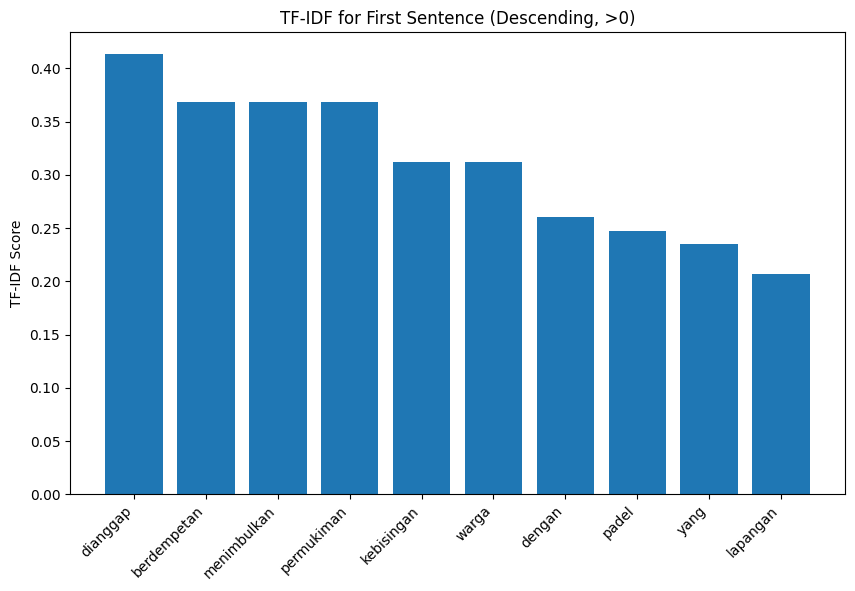

In [7]:
first_sentence_tfidf = tfidf_df.iloc[0]

first_sentence_tfidf = first_sentence_tfidf[first_sentence_tfidf > 0].sort_values(ascending=False)

# plot
plt.figure(figsize=(10, 6))
plt.bar(first_sentence_tfidf.index, first_sentence_tfidf.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF for First Sentence (Descending, >0)")
plt.show()

Text Summarization

In [9]:
averages = []

for index, data in tfidf_df.iterrows():
    row_average = 0
    # get average of tf-idf for all words that appear in the sentence
    if (data != 0).sum() > 0:
        row_average = data.sum() / (data != 0).sum()

        averages.append(row_average)

# using first sentence tf-idf as the base threshold
threshold = averages[0]

print(f"Minimum value: {threshold}")
for i in range(0, len(averages)):
    print(f"Sentence {i + 1} value: {averages[i]}")

final_result = ""
final_result_neat = ""

sentences_in_summary = []
for i in range(len(averages)):
    if (averages[i] >= threshold):
        final_result +=  " " + sentences_dirty[i]
        final_result_neat += " " + sentences_dirty[i] + "\n"
        sentences_in_summary.append(i)

print("\nSentences in summary:")
print(sentences_in_summary)

Minimum value: 0.3092483574404395
Sentence 1 value: 0.3092483574404395
Sentence 2 value: 0.5765407742296323
Sentence 3 value: 0.2621319771769092
Sentence 4 value: 0.24727779698755964
Sentence 5 value: 0.2624187308255307
Sentence 6 value: 0.23131005291422102
Sentence 7 value: 0.29588682291521057
Sentence 8 value: 0.2083122594785105
Sentence 9 value: 0.3295106493392957
Sentence 10 value: 0.2525921885243533
Sentence 11 value: 0.3473669726803303
Sentence 12 value: 0.2957011169357908
Sentence 13 value: 0.20244383802649268
Sentence 14 value: 0.3500059187104125
Sentence 15 value: 0.2257201046518389
Sentence 16 value: 0.2646967413864419
Sentence 17 value: 0.2994732857291066
Sentence 18 value: 0.23230876365606534
Sentence 19 value: 0.32958207861267474
Sentence 20 value: 0.24622194585852306
Sentence 21 value: 0.32215392276592225
Sentence 22 value: 0.23755656524250596
Sentence 23 value: 0.2729888235818635
Sentence 24 value: 0.20660241164836712
Sentence 25 value: 0.19902734418305545
Sentence 26 va